# Complex Step Derivative

The complex step derivative is a numerical differentiation technique that evaluates derivatives using complex arithmetic. Unlike finite-difference methods, it avoids subtractive cancellation and therefore provides highly accurate derivative approximations even for extremely small step sizes. This method is particularly useful in optimization, sensitivity analysis, and scientific computing, where accurate numerical derivatives are essential.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Complex Step Approximation

For an analytic function $f(x)$, the derivative can be approximated by evaluating the function at a complex-valued argument,

$$
f'(x)\approx\frac{\operatorname{Im}\left[f(x+i\Delta x)\right]}{\Delta x},
$$

where $\operatorname{Im}(\cdot)$ denotes the imaginary part and $\Delta x$ is a small perturbation. Unlike finite differences, this approximation does not involve subtracting nearly equal numbers, allowing the step size to approach machine precision without significant round-off error.

In [3]:
def complex_derivative(f, x, h=1e-20):
    return np.imag(f(x + 1j*h)) / h

## Numerical Force

The force is obtained from the time derivative of the momentum,

$$
F(t)=\frac{dp}{dt},
$$

where

$$
p(t)=mv(t).
$$

The resulting force profile is evaluated using the complex step derivative and visualized over the entire simulation interval.

In [4]:
m = 4e5
v = lambda t: (100 / (1 + np.exp(-0.05*(t-100)))) - (100 / (1 + np.exp(-0.02*(t-950))))
p = lambda t: m * v(t)
F = lambda t: m * (5 * np.exp(-0.05*(t-100)) / (1 + np.exp(-0.05*(t-100)))**2 - 2 * np.exp(-0.02*(t-950)) / (1 + np.exp(-0.02*(t-950)))**2)

The following code computes the force acting on a moving particle by differentiating the momentum $p(t)=mv(t)$ using the complex step derivative.

In [5]:
t = np.linspace(0, 1200, 2400)
dp_dt = complex_derivative(p, t)

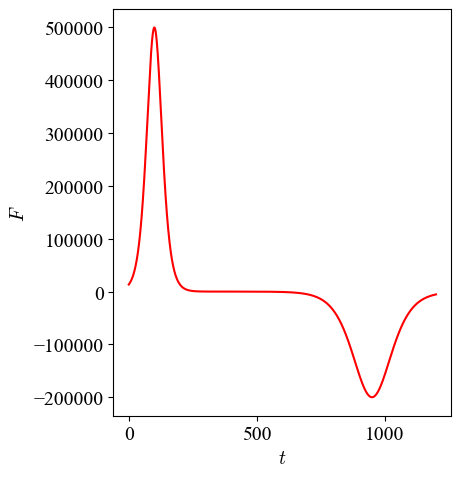

In [6]:
plt.figure(figsize=(5, 5))
plt.plot(t, dp_dt, color="r")
plt.xlabel(r"$t$")
plt.ylabel(r"$F$")
plt.tight_layout()
plt.show()

## Error Analysis

To assess the numerical accuracy, the complex step derivative is compared with the central finite-difference approximation for a wide range of step sizes. The absolute error is computed with respect to the analytical derivative,

$$
|e|=\left|F_{\mathrm{num}}-F_{\mathrm{exact}}\right|.
$$

The following comparison illustrates the effect of the step size on the accuracy of both numerical differentiation methods.

In [7]:
def central_difference(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

In [8]:
dt_values = np.logspace(1, -16, 2000)
t0, exact = 100, F(100)
err_cd = [abs(central_difference(p, t0, h) - exact) for h in dt_values]
err_cs = [abs(complex_derivative(p, t0, h) - exact) for h in dt_values]

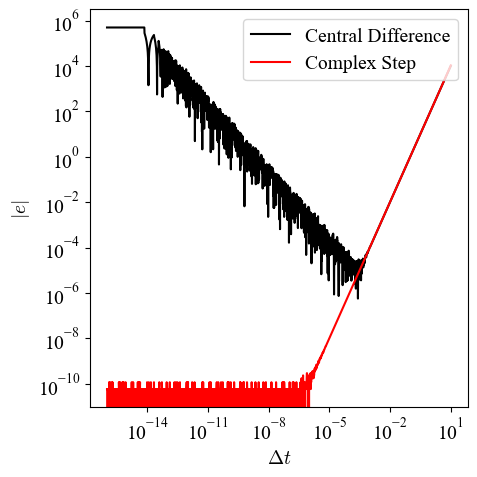

In [9]:
plt.figure(figsize=(5, 5))
plt.loglog(dt_values, err_cd, color="k", label="Central Difference")
plt.loglog(dt_values, err_cs, color="r", label="Complex Step")
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$|e|$")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Key Insights

* The complex step derivative computes numerical derivatives using complex-valued perturbations.
* Unlike finite differences, it avoids subtractive cancellation and maintains high accuracy for very small step sizes.
* Central finite differences are limited by truncation and round-off errors as the step size decreases.
* The complex step method achieves near machine-precision accuracy over a broad range of perturbation sizes.